<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/run-notebooks-colab/notebooks/gradchecks/GradCheck_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mtlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.3/544.3 kB 6.2 MB/s eta 0:00:00


In [1]:
from mtlearn import morphology
import mtlearn

import torch
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import time

import torch
from torch.autograd import gradcheck

In [2]:
torch.set_printoptions(precision=16, sci_mode=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32

## 1 - Gradient Checks

misc256: already available at /Volumes/SSD/GitHub/mtlearn/dat/misc256


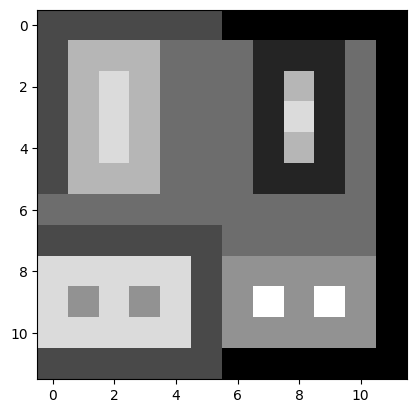

In [3]:
resize_proportion = 0.5

sample_image = sorted(mtlearn.data.ensure_dataset('misc256').glob('*.png'))[0]
original_image = cv.imread(str(sample_image), 0)
(num_rows, num_cols) = original_image.shape

height, width = original_image.shape
height = int(height * resize_proportion)
width = int(width * resize_proportion)

image = cv.resize(original_image, (width, height), interpolation=cv.INTER_LINEAR)

image =  np.array([
        [2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
        [2, 5, 5, 5, 3, 3, 3, 1, 1, 1, 3, 0],
        [2, 5, 6, 5, 3, 3, 3, 1, 5, 1, 3, 0],
        [2, 5, 6, 5, 3, 3, 3, 1, 6, 1, 3, 0],
        [2, 5, 6, 5, 3, 3, 3, 1, 5, 1, 3, 0],
        [2, 5, 5, 5, 3, 3, 3, 1, 1, 1, 3, 0],
        [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0],
        [2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 0],
        [6, 6, 6, 6, 6, 2, 4, 4, 4, 4, 4, 0],
        [6, 4, 6, 4, 6, 2, 4, 7, 4, 7, 4, 0],
        [6, 6, 6, 6, 6, 2, 4, 4, 4, 4, 4, 0],
        [2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0]
    ])

tree = morphology.create_max_tree(image)

plt.imshow(image, 'gray')
height, width = image.shape

### 1.1 - Attribute Extraction

In [4]:
AttributeType = morphology.AttributeType

attributes = morphology.compute_attributes(tree, [AttributeType.AREA, AttributeType.COMPACTNESS])[1]

# Min-max normalization to the [0, 1] range
attributes = (attributes.min() - attributes) / (attributes - attributes.max() + 1e-8)

attributes = torch.as_tensor(attributes, dtype=dtype).to(device)

### 1.2 - Weight and Bias Initialization

In [5]:
weight = torch.nn.Parameter(torch.empty(attributes.shape[1], dtype=dtype, device=device), requires_grad=True)
weight.data.fill_(1)

bias = torch.nn.Parameter(torch.empty(1, dtype=dtype, device=device), requires_grad=True)
bias.data.fill_(0)

beta_f = 1
clamp_logits = False

### 1.4 - Numerical Gradient Computation

Parameter initialization with positive and negative perturbations

In [6]:
eps = 3e-4
atol = 1e-3

w0_increased = weight.clone()
w0_increased[0] += eps
w0_decreased = weight.clone()
w0_decreased[0] -= eps

w1_increased = weight.clone()
w1_increased[1] += eps
w1_decreased = weight.clone()
w1_decreased[1] -= eps

bias_increased = bias.clone()
bias_increased[0] += eps
bias_decreased = bias.clone()
bias_decreased[0] -= eps

In [7]:
def numeric_gradient_weight(function, weight_increased, weight_decreased, bias):
    return ((function(tree, attributes, weight_increased, bias, beta_f, clamp_logits) - function(tree, attributes, weight_decreased, bias, beta_f, clamp_logits)) / (2 * eps)).mean()

def numeric_gradient_bias(function, weight, bias_increased, bias_decreased):
    return ((function(tree, attributes, weight, bias_increased, beta_f, clamp_logits) - function(tree, attributes, weight, bias_decreased, beta_f, clamp_logits)) / (2 * eps)).mean()

#### 1.4.1 - Gradient for ```weight[0]```

In [8]:
numeric_grad_w0 = numeric_gradient_weight(
    mtlearn.layers.ConnectedFilterPreprocessingCPUTreeTraversalFunction.apply,
    w0_increased,
    w0_decreased,
    bias
)

#### 1.4.2 - Gradient for ```weight[1]```

In [9]:
numeric_grad_w1 = numeric_gradient_weight(
    mtlearn.layers.ConnectedFilterPreprocessingCPUTreeTraversalFunction.apply,
    w1_increased,
    w1_decreased,
    bias
)

#### 1.4.3 - Gradient for ```bias```

In [10]:
numeric_grad_bias = numeric_gradient_bias(
    mtlearn.layers.ConnectedFilterPreprocessingCPUTreeTraversalFunction.apply,
    weight,
    bias_increased,
    bias_decreased,
)

In [11]:
numeric_grad_w0, numeric_grad_w1, numeric_grad_bias

(tensor(0.2268508523702621, grad_fn=<MeanBackward0>),
 tensor(0.0001572900364408, grad_fn=<MeanBackward0>),
 tensor(0.3495729565620422, grad_fn=<MeanBackward0>))

### 1.5 - Analytical Gradient

In [12]:
filtered_image = mtlearn.layers.ConnectedFilterPreprocessingCPUTreeTraversalFunction.apply(tree, attributes, weight, bias, beta_f, clamp_logits)

output_scalar = filtered_image.mean()
output_scalar.backward()
weight.grad, bias.grad

(tensor([0.2268708497285843, 0.0001228299370268]),
 tensor([0.3495558500289917]))

### 1.6 - Numerical vs Analytical Gradient Comparison

In [13]:
(
    (weight.grad[0] - numeric_grad_w0).abs(),
    (weight.grad[1] - numeric_grad_w1).abs(),
    (bias.grad - numeric_grad_bias).abs()
)

(tensor(0.0000199973583221, grad_fn=<AbsBackward0>),
 tensor(0.0000344600994140, grad_fn=<AbsBackward0>),
 tensor([0.0000171065330505], grad_fn=<AbsBackward0>))

In [14]:
print(f'weight[0]: {(weight.grad[0] - numeric_grad_w0).abs().item()}')
print(f'weight[1]: {(weight.grad[1] - numeric_grad_w1).abs().item()}')
print(f'bias: {(bias.grad - numeric_grad_bias).abs().item()}')

weight[0]: 1.9997358322143555e-05
weight[1]: 3.4460099413990974e-05
bias: 1.710653305053711e-05


### 1.7 - Gradient Checking

In [15]:


success_counter = 0
fail_counter = 0

def filtered_pixel(weight, bias, pixel_index):
    return mtlearn.layers.ConnectedFilterPreprocessingCPUTreeTraversalFunction.apply(tree, attributes, weight, bias, beta_f, clamp_logits).flatten()[pixel_index]


for pixel_index in range(len(image.flatten())):
    if pixel_index % 1000 == 0:
        print(f'{pixel_index} | Success: {success_counter} | Fail: {fail_counter}')

    parameters = (weight, bias, pixel_index)

    try:
        gradcheck(filtered_pixel, parameters, eps=eps, atol=atol)
        success_counter += 1

    except:
        fail_counter += 1

print("Success: ", success_counter)
print("Fail: ", fail_counter)

0 | Success: 0 | Fail: 0


/opt/anaconda3/lib/python3.12/site-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #0 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)
/opt/anaconda3/lib/python3.12/site-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #1 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)


Success:  144
Fail:  0


/opt/anaconda3/lib/python3.12/site-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #0 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)
/opt/anaconda3/lib/python3.12/site-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #1 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)
